# AAE Raman -> Single-Cell Training (Reorganized)

This notebook reorganizes the AAE workflow from `AAE_Raman_single_cell_analysis.ipynb`.
- Functions grouped together.
- Training steps grouped together.
- Each figure in its own cell, saved to `results/figure4` as pdf/svg/png.


## Streamlined Pipeline

Retained sections only: data import, model definitions, training, test evaluation, expression-level validation, marker-gene visualization, and expression scatter / pseudo-bulk comparison.


In [1]:
# Role: Environment setup, imports, device selection, and output directory configuration.
import os
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import scanpy as sc
import anndata
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Global config
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("results/figure4")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = RESULTS_DIR
sc.settings.autoshow = False


Using device: cuda


In [2]:
# Role: Utility helpers for dense conversion, plotting, figure saving, and model device lookup.
def ensure_dense(x):
    if sp.sparse.issparse(x):
        return x.toarray()
    if hasattr(x, "toarray"):
        return x.toarray()
    if hasattr(x, "todense"):
        return np.asarray(x.todense())
    return np.asarray(x)


def save_figure(fig, name, dpi=300, show=True):
    for ext in ["png", "pdf", "svg"]:
        fig.savefig(RESULTS_DIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


def plot_loss_curve(losses, title, ylabel, name):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(losses, lw=2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    # save_figure(fig, name)


def plot_roc_multiclass(y_true, y_score, class_names, name):
    y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(6, 5))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{cls} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title("ROC Curves (One-vs-Rest)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    save_figure(fig, name)


def plot_expression_consistency(
    adata,
    genes,
    batch_key="batch",
    group_key="cell_type",
    batch_a="SingleCell",
    batch_b="Raman_Train",
    title="Expression Consistency",
    name="expr_consistency",
):
    genes = [g for g in genes if g in adata.var_names]
    if len(genes) == 0:
        print("No genes found for plotting.")
        return

    df = []
    for ct in adata.obs[group_key].unique():
        for b in [batch_a, batch_b]:
            sub = adata[(adata.obs[group_key] == ct) & (adata.obs[batch_key] == b)]
            if sub.n_obs == 0:
                continue
            expr = np.asarray(sub[:, genes].X)
            if sp.sparse.issparse(expr):
                expr = expr.toarray()
            mean_expr = expr.mean(axis=0)
            for g, val in zip(genes, mean_expr):
                df.append({"cell_type": ct, "batch": b, "gene": g, "mean_expr": val})

    df = pd.DataFrame(df)
    df_a = df[df["batch"] == batch_a].set_index(["cell_type", "gene"])
    df_b = df[df["batch"] == batch_b].set_index(["cell_type", "gene"])
    df_join = df_a.join(df_b, lsuffix="_a", rsuffix="_b", how="inner")

    fig, ax = plt.subplots(figsize=(6, 5))
    for ct in df_join.index.get_level_values(0).unique():
        sub = df_join.loc[ct]
        ax.scatter(sub["mean_expr_a"], sub["mean_expr_b"], label=str(ct), s=30, alpha=0.8)
    ax.set_xlabel(f"{batch_a} mean expression")
    ax.set_ylabel(f"{batch_b} mean expression")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    save_figure(fig, name)


def get_model_device(model):
    return next(model.parameters()).device


In [3]:
# Role: Model definitions for encoder, decoder, discriminator, and VAE wrapper.
class StandardEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=512):
        super(StandardEncoder, self).__init__()
        self.part1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )
        self.to_mean = nn.Linear(hidden_dim, latent_dim)
        self.to_logvar = nn.Linear(hidden_dim, latent_dim)
        self.latent_dim = latent_dim

    def forward(self, x):
        x = self.part1(x)
        return self.to_mean(x), self.to_logvar(x)


class StandardDecoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=512, no_final_relu=False):
        super(StandardDecoder, self).__init__()
        if no_final_relu:
            self.net = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, input_dim),
            )
        else:
            self.net = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, input_dim),
                nn.ReLU(),
            )
        self.latent_dim = latent_dim

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self, latent_dim, spectral=True, end_dim=2):
        super(Discriminator, self).__init__()
        if spectral:
            self.net = nn.Sequential(
                nn.utils.spectral_norm(nn.Linear(latent_dim, 1 << 6)),
                nn.ReLU(),
                nn.utils.spectral_norm(nn.Linear(1 << 6, 1 << 5)),
                nn.ReLU(),
                nn.utils.spectral_norm(nn.Linear(1 << 5, 1 << 5)),
                nn.ReLU(),
                nn.utils.spectral_norm(nn.Linear(1 << 5, end_dim)),
            )
        else:
            self.net = nn.Sequential(
                nn.Linear(latent_dim, 1 << 6),
                nn.ReLU(),
                nn.Linear(1 << 6, 1 << 5),
                nn.ReLU(),
                nn.Linear(1 << 5, 1 << 5),
                nn.ReLU(),
                nn.Linear(1 << 5, end_dim),
            )

    def forward(self, x):
        return self.net(x)


class VAE(nn.Module):
    def __init__(self, encoder, decoder, is_vae=True, use_latent_norm=True):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.is_vae = is_vae
        self.latent_normalizer = nn.BatchNorm1d(self.encoder.latent_dim)
        self.use_latent_norm = use_latent_norm

    def reparam_trick(self, mean, logvar):
        # VAE: sample; AE: deterministic (return mean)
        if not self.is_vae:
            return mean
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        return mean + eps * sigma

    def get_latent(self, x):
        mean, logvar = self.encoder(x)

        # ✅ AE 模式：logvar 不参与任何 BN（避免污染 running stats）
        if not self.is_vae:
            latent = mean
            if self.use_latent_norm:
                latent = self.latent_normalizer(latent)
            return latent

        # ✅ VAE 模式：按你原来的思路（可选择是否也 BN logvar）
        if self.use_latent_norm:
            mean = self.latent_normalizer(mean)
            # 这行可留可不留；保守起见我不对 logvar 用同一个 BN
            # logvar = self.latent_normalizer(logvar)
        latent = self.reparam_trick(mean, logvar)
        if self.use_latent_norm:
            latent = self.latent_normalizer(latent)
        return latent

    def forward(self, x, noise_latent_lambda=0.0):
        mean, logvar = self.encoder(x)

        if not self.is_vae:
            latent = mean
            if self.use_latent_norm:
                latent = self.latent_normalizer(latent)
        else:
            if self.use_latent_norm:
                mean = self.latent_normalizer(mean)
                # 同上：通常不建议用同一个 BN 去处理 logvar
                # logvar = self.latent_normalizer(logvar)
            latent = self.reparam_trick(mean, logvar)
            if self.use_latent_norm:
                latent = self.latent_normalizer(latent)

        if noise_latent_lambda:
            latent = latent + noise_latent_lambda * torch.randn_like(latent)

        recon_x = self.decoder(latent)
        return recon_x, mean, logvar, latent


In [4]:
# Role: Loss functions for reconstruction, adversarial alignment, and discriminator training.
def old_vae_loss(x, recon_x, mean, logvar, weights=None, this_lambda=0.0):
    if weights is None:
        bce = F.mse_loss(recon_x, x)
    else:
        bce = torch.sum(((recon_x - x) ** 2) * weights)
    kl_div = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    return bce + this_lambda * kl_div


def discrim_loss(pred, true):
    return F.binary_cross_entropy_with_logits(pred, true)


def adv_vae_loss(x, recon_x, mean, logvar, discrim_preds, alpha, beta, weights=None):
    vae_part_loss = old_vae_loss(x, recon_x, mean, logvar, weights=weights)
    source_label = [1.0, 0.0]
    discrim_labels = torch.tensor([source_label] * x.shape[0]).to(x.device)
    total_discrim_loss = F.binary_cross_entropy_with_logits(discrim_preds, discrim_labels)
    discrim_part_loss = beta * total_discrim_loss
    return alpha * vae_part_loss + discrim_part_loss, vae_part_loss, total_discrim_loss


In [5]:
# ==== MODIFIED (2026-03-19) ====
# Purpose: Use SC normalized layer (layers['data']) so SC/Raman inputs share the same scale.
# ===============================
# Role: Load SC/Raman AnnData objects and align SC training matrix to the chosen input layer.
abc_ad = sc.read_h5ad("./data/abc_B_lineage_processed.h5ad")
raman_ad = sc.read_h5ad("./data/raman_B.h5ad")

highly_variable_genes = abc_ad.var_names[abc_ad.var["highly_variable"]]
train_feature_ad = abc_ad[:, highly_variable_genes].copy()

# Keep SC and Raman on the same scale: use normalized SC layer as training target
if "data" not in train_feature_ad.layers:
    raise KeyError("train_feature_ad.layers['data'] is required but not found.")
train_feature = ensure_dense(train_feature_ad.layers["data"])
raman_X = ensure_dense(raman_ad.X)

print(abc_ad)
print(raman_ad)
print("SC train matrix from layer=data:", train_feature.shape, "Raman matrix:", raman_X.shape)


AnnData object with n_obs × n_vars = 938 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'data'
    obsp: 'connectivities', 'dist

In [6]:
# Role: Define cell-type ordering, palettes, and categorical metadata for plotting.
# Fixed cell type order and hard-coded colors (match LDA plots)
ORDER = ["HSC", "Pro B", "Pre B", "Naive B"]
class_color_map = {
    "HSC": "#1f77b4",    # blue
    "Pro B": "#17becf",  # cyan
    "Pre B": "#e377c2",  # pink
    "Naive B": "#d62728" # red
}
classes = np.array(ORDER)
abc_ad.obs["cell_type"] = pd.Categorical(abc_ad.obs["cell_type"], categories=classes, ordered=True)
train_feature_ad.obs["cell_type"] = pd.Categorical(train_feature_ad.obs["cell_type"], categories=classes, ordered=True)
raman_ad.obs["cell_type"] = pd.Categorical(raman_ad.obs["cell_type"], categories=classes, ordered=True)
abc_ad.uns["cell_type_colors"] = [class_color_map[c] for c in classes]
palette = [class_color_map[c] for c in classes]

cell_type_sorted = abc_ad.obs["cell_type"].astype(str).values
row_colors = np.array([class_color_map[ct] for ct in cell_type_sorted])


In [7]:
# Role: Build SC train/test splits and dataloaders for ref VAE and classifier training.
labels = train_feature_ad.obs["cell_type"].astype(str)
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

train_data, test_data, train_labels, test_labels = train_test_split(
    train_feature,
    labels_encoded,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded,
)

train_tensor = torch.tensor(train_data, dtype=torch.float32)
test_tensor = torch.tensor(test_data, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

batch_size = 1 << 5
train_dataset = TensorDataset(train_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(train_tensor.shape, test_tensor.shape)


torch.Size([750, 2000]) torch.Size([188, 2000])


In [8]:
# ==== MODIFIED (2026-03-19) ====
# Purpose: Disable latent BN in ref_vae (use_latent_norm=False) and keep corrected epoch loss averaging.
# ===============================
# Role: Train the reference SC autoencoder used as latent anchor and expression decoder.
epochs_ref_vae = 10
input_dim = train_data.shape[1]

ref_vae = VAE(
    StandardEncoder(input_dim, 1 << 7, hidden_dim=1 << 11),
    StandardDecoder(input_dim, 1 << 7, hidden_dim=1 << 11),
    is_vae=False,
    use_latent_norm=False,
).to(device)

ref_vae_opt = optim.Adam(ref_vae.parameters(), lr=1e-3)

ref_vae_losses = []
for epoch in range(1, epochs_ref_vae + 1):
    epoch_loss = 0.0
    seen = 0
    for _id, (batch, labels) in enumerate(train_loader):
        batch = batch.to(device)
        ref_vae_opt.zero_grad()
        recon_x, mean, logvar, latent = ref_vae(batch)
        batch_loss = old_vae_loss(batch, recon_x, mean, logvar, weights=None)
        batch_loss.backward()
        ref_vae_opt.step()
        bs = batch.size(0)
        epoch_loss += batch_loss.item() * bs
        seen += bs
    avg_loss = epoch_loss / max(seen, 1)
    ref_vae_losses.append(avg_loss)
    print(f"RefVAE Epoch {epoch}: avg_loss={avg_loss:.6f}")


RefVAE Epoch 1: avg_loss=0.351152
RefVAE Epoch 2: avg_loss=0.316276
RefVAE Epoch 3: avg_loss=0.311841
RefVAE Epoch 4: avg_loss=0.305812
RefVAE Epoch 5: avg_loss=0.303643
RefVAE Epoch 6: avg_loss=0.302912
RefVAE Epoch 7: avg_loss=0.306318
RefVAE Epoch 8: avg_loss=0.303013
RefVAE Epoch 9: avg_loss=0.302798
RefVAE Epoch 10: avg_loss=0.304797


In [9]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# Role: Extract SC latent embeddings and train the SC cell-type classifier.
ref_vae_eval = ref_vae.to(device).eval()
with torch.no_grad():
    train_tensor_dev = torch.tensor(train_data, dtype=torch.float32, device=get_model_device(ref_vae_eval))
    test_tensor_dev = torch.tensor(test_data, dtype=torch.float32, device=get_model_device(ref_vae_eval))
    _, _, _, latent_train = ref_vae_eval(train_tensor_dev)
    _, _, _, latent_test = ref_vae_eval(test_tensor_dev)

latent_train = latent_train.detach().cpu()
latent_test = latent_test.detach().cpu()

latent_dim = 1 << 7
num_classes = len(np.unique(train_labels))

celltype_classifier = Discriminator(latent_dim, end_dim=num_classes).to(device)
celltype_classifier_opt = optim.Adam(celltype_classifier.parameters(), lr=1e-3)

class_weights = torch.tensor([
    float(len(train_labels)) / np.sum(train_labels == class_label)
    for class_label in range(num_classes)
], dtype=torch.float32).to(device)
criter = nn.CrossEntropyLoss(weight=class_weights)

celltype_data_loader = DataLoader(
    TensorDataset(latent_train, torch.tensor(train_labels, dtype=torch.long)),
    batch_size=batch_size,
    shuffle=True,
)

classifier_loss_history = []
classifier_acc_history = []

epochs_classifier = 50
for epoch in range(1, epochs_classifier + 1):
    epoch_loss = 0.0
    correct = 0
    total = 0
    for this_batch, this_label in celltype_data_loader:
        this_batch = this_batch.to(device)
        this_label = this_label.to(device)
        celltype_classifier_opt.zero_grad()
        logits = celltype_classifier(this_batch.float())
        loss = criter(logits, this_label)
        loss.backward()
        celltype_classifier_opt.step()
        epoch_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == this_label).sum().item()
        total += this_label.size(0)
    avg_loss = epoch_loss / len(celltype_data_loader.dataset)
    acc = correct / total
    classifier_loss_history.append(avg_loss)
    classifier_acc_history.append(acc)
    print(f"Classifier Epoch {epoch}: avg_loss={avg_loss:.6f}, acc={acc:.4f}")


Classifier Epoch 1: avg_loss=0.028950, acc=0.8600
Classifier Epoch 2: avg_loss=0.008795, acc=0.9707
Classifier Epoch 3: avg_loss=0.005687, acc=0.9640
Classifier Epoch 4: avg_loss=0.004177, acc=0.9747
Classifier Epoch 5: avg_loss=0.004535, acc=0.9733
Classifier Epoch 6: avg_loss=0.005214, acc=0.9680
Classifier Epoch 7: avg_loss=0.003643, acc=0.9747
Classifier Epoch 8: avg_loss=0.003825, acc=0.9733
Classifier Epoch 9: avg_loss=0.003438, acc=0.9773
Classifier Epoch 10: avg_loss=0.003341, acc=0.9733
Classifier Epoch 11: avg_loss=0.003891, acc=0.9720
Classifier Epoch 12: avg_loss=0.004053, acc=0.9680
Classifier Epoch 13: avg_loss=0.003154, acc=0.9773
Classifier Epoch 14: avg_loss=0.003239, acc=0.9773
Classifier Epoch 15: avg_loss=0.003079, acc=0.9760
Classifier Epoch 16: avg_loss=0.003630, acc=0.9760
Classifier Epoch 17: avg_loss=0.003669, acc=0.9760
Classifier Epoch 18: avg_loss=0.003451, acc=0.9773
Classifier Epoch 19: avg_loss=0.003722, acc=0.9773
Classifier Epoch 20: avg_loss=0.003295, 

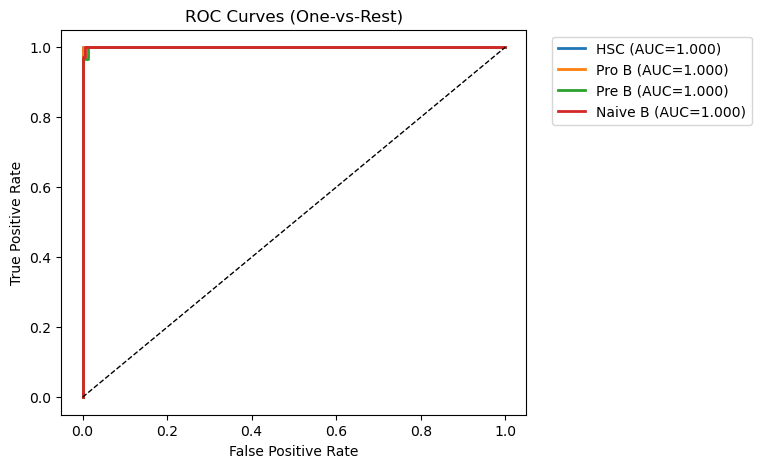

LabelEncoder order: ['HSC', 'Naive B', 'Pre B', 'Pro B']
Holdout test accuracy: 0.9840425531914894
Confusion matrix (rows=true, cols=pred):
[[53  0  0  0]
 [ 0 69  0  0]
 [ 0  0 28  3]
 [ 0  0  0 35]]


In [10]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# Role: Evaluate SC classifier on holdout SC latent and print ROC/diagnostic summary.
celltype_classifier_eval = celltype_classifier.to(device).eval()
with torch.no_grad():
    latent_test_dev = latent_test.to(get_model_device(celltype_classifier_eval))
    test_logits = celltype_classifier_eval(latent_test_dev.float())
    test_probs = torch.softmax(test_logits, dim=1).cpu().numpy()

plot_roc_multiclass(test_labels, test_probs, classes, "classifier_roc")

from sklearn.metrics import confusion_matrix
pred_test = np.argmax(test_probs, axis=1)
test_acc = np.mean(pred_test == test_labels)
print('LabelEncoder order:', list(label_encoder.classes_))
print('Holdout test accuracy:', float(test_acc))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(test_labels, pred_test))


In [11]:
# Role: Build Raman train/test splits and dataloaders.
raman_y = label_encoder.transform(raman_ad.obs["cell_type"].astype(str).values)
raman_X_train, raman_X_test, raman_y_train, raman_y_test = train_test_split(
    raman_X,
    raman_y,
    test_size=0.2,
    random_state=42,
    stratify=raman_y,
)

raman_index = raman_ad.obs.index
raman_index_train, raman_index_test = train_test_split(
    raman_index,
    test_size=0.2,
    random_state=42,
    stratify=raman_y,
)

raman_train_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(raman_X_train).float(),
        torch.from_numpy(raman_y_train).long(),
    ),
    batch_size=batch_size,
    shuffle=True,
)

raman_test_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(raman_X_test).float(),
        torch.from_numpy(raman_y_test).long(),
    ),
    batch_size=batch_size,
    shuffle=False,
)


In [12]:
# ==== MODIFIED (2026-03-19) ====
# Latent-only training (recon + adv + celltype),
# with non-truncating loader pairing (cycle ref loader instead of zip truncation).
# Role: Train Raman adversarial autoencoder with latent-only objective against the SC reference space.
latent_dim = 1 << 7
ref_vae = ref_vae.to(device).eval()

input_cell_dim = raman_X.shape[1]
raman_vae = VAE(
    StandardEncoder(input_cell_dim, latent_dim, hidden_dim=1 << 11),
    StandardDecoder(input_cell_dim, latent_dim, hidden_dim=1 << 11, no_final_relu=True),
    is_vae=False,
    use_latent_norm=False,
).to(device)
raman_opt = optim.Adam(raman_vae.parameters(), lr=5e-5)

raman_discrim = Discriminator(latent_dim).to(device)
raman_discrim_opt = optim.Adam(raman_discrim.parameters(), lr=4e-3)

# Keep latent-only objective and original alpha
alpha = 1.0
beta = 0.05        # stronger adversarial pressure so latent alignment is not drowned out
raman_beta = 5.0    # reduce celltype dominance; keep label signal but make it auxiliary

celltype_classifier = celltype_classifier.to(device).eval()
for p in celltype_classifier.parameters():
    p.requires_grad = False

ref_data_loader = DataLoader(
    TensorDataset(torch.from_numpy(train_feature).float()),
    batch_size=batch_size,
    shuffle=True,
)

epochs_raman = 50
loss_adv = []
loss_vae = []
loss_celltype = []
loss_discrim = []
domain_acc_epoch = []

for epoch in range(1, epochs_raman + 1):
    discrim_epoch_loss = 0.0
    vae_part_epoch_loss = 0.0
    raman_vae_epoch_loss = 0.0
    celltype_part_epoch_loss = 0.0
    seen = 0

    ref_iter = iter(ref_data_loader)
    for _id, (raman_batch, raman_celltypes) in enumerate(raman_train_loader):
        try:
            (ref_batch,) = next(ref_iter)
        except StopIteration:
            ref_iter = iter(ref_data_loader)
            (ref_batch,) = next(ref_iter)

        raman_opt.zero_grad()
        raman_discrim_opt.zero_grad()

        ref_batch = ref_batch.to(device)
        raman_batch = raman_batch.to(device)
        raman_celltypes = raman_celltypes.to(device)
        bs = raman_batch.size(0)

        # Step A: train domain discriminator
        ref_encoded = ref_vae.get_latent(ref_batch).detach()
        raman_encoded = raman_vae.get_latent(raman_batch).detach()

        source_label, target_label = [1.0, 0.0], [0.0, 1.0]
        encodeds = torch.cat((ref_encoded, raman_encoded), axis=0)
        discrim_labels = torch.tensor(
            [source_label] * ref_encoded.shape[0] + [target_label] * raman_encoded.shape[0],
            device=device,
        )

        pred_discrim_labels = raman_discrim(encodeds)
        batch_discrim_loss = discrim_loss(pred_discrim_labels, discrim_labels)
        batch_discrim_loss.backward()
        discrim_epoch_loss += batch_discrim_loss.item() * bs
        raman_discrim_opt.step()

        # Step B: train Raman VAE (freeze discriminator)
        for param in raman_discrim.parameters():
            param.requires_grad = False

        recon_raman_batch, raman_batch_mean, raman_batch_logvar, raman_batch_latent = raman_vae(raman_batch)
        raman_vae_discrim_preds = raman_discrim(raman_batch_latent)

        raman_vae_batch_loss, vae_part_batch_loss, _ = adv_vae_loss(
            raman_batch.detach(),
            recon_raman_batch,
            raman_batch_mean,
            raman_batch_logvar,
            raman_vae_discrim_preds,
            alpha,
            beta,
        )

        raman_celltype_preds = celltype_classifier(raman_batch_latent)
        raman_celltype_loss = criter(raman_celltype_preds, raman_celltypes)
        raman_vae_batch_loss = raman_vae_batch_loss + raman_beta * raman_celltype_loss

        raman_vae_batch_loss.backward()
        celltype_part_epoch_loss += raman_celltype_loss.item() * bs
        raman_vae_epoch_loss += raman_vae_batch_loss.item() * bs
        vae_part_epoch_loss += vae_part_batch_loss.item() * bs
        seen += bs
        raman_opt.step()

        for param in raman_discrim.parameters():
            param.requires_grad = True

    # Epoch averages
    loss_adv.append(raman_vae_epoch_loss / max(seen, 1))
    loss_vae.append(vae_part_epoch_loss / max(seen, 1))
    loss_celltype.append(celltype_part_epoch_loss / max(seen, 1))
    loss_discrim.append(discrim_epoch_loss / max(seen, 1))

    # Domain discriminator accuracy (full data snapshot)
    with torch.no_grad():
        z_ref_all = ref_vae.get_latent(torch.from_numpy(train_feature).float().to(device))
        z_ram_all = raman_vae.get_latent(torch.from_numpy(raman_X).float().to(device))
        z_all = torch.cat([z_ref_all, z_ram_all], dim=0)
        logits_all = raman_discrim(z_all)
        pred_all = torch.argmax(logits_all, dim=1).cpu().numpy()
        y_all = np.array([0] * z_ref_all.shape[0] + [1] * z_ram_all.shape[0])
        dacc = float((pred_all == y_all).mean())
        domain_acc_epoch.append(dacc)

    print(
        f"Raman Epoch {epoch}: adv={loss_adv[-1]:.6f}, vae={loss_vae[-1]:.6f}, "
        f"celltype={loss_celltype[-1]:.6f}, discrim={loss_discrim[-1]:.6f}, dacc={domain_acc_epoch[-1]:.4f}"
    )


Raman Epoch 1: adv=8.036256, vae=0.067036, celltype=0.397827, discrim=0.316101, dacc=0.9983
Raman Epoch 2: adv=3.107001, vae=0.008084, celltype=0.153774, discrim=0.118743, dacc=0.9983
Raman Epoch 3: adv=1.237686, vae=0.002740, celltype=0.060411, discrim=0.082158, dacc=0.9987
Raman Epoch 4: adv=1.113547, vae=0.001524, celltype=0.054168, discrim=0.071828, dacc=0.9992
Raman Epoch 5: adv=0.942297, vae=0.001156, celltype=0.045593, discrim=0.069112, dacc=0.9992
Raman Epoch 6: adv=1.021003, vae=0.000885, celltype=0.049467, discrim=0.061039, dacc=0.9992
Raman Epoch 7: adv=1.812160, vae=0.000799, celltype=0.089056, discrim=0.059765, dacc=0.9992
Raman Epoch 8: adv=1.331172, vae=0.000626, celltype=0.064992, discrim=0.060715, dacc=0.9992
Raman Epoch 9: adv=0.584386, vae=0.000599, celltype=0.027605, discrim=0.054951, dacc=0.9992
Raman Epoch 10: adv=0.473535, vae=0.000434, celltype=0.022045, discrim=0.053627, dacc=0.9996
Raman Epoch 11: adv=0.225733, vae=0.000400, celltype=0.009657, discrim=0.051141

/tmp/ipykernel_201112/1834576216.py:41: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  together_recon = recon_adata_singlecell.concatenate(
/data/liulab/chenming/software/miniforge3/envs/hla_gnn_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


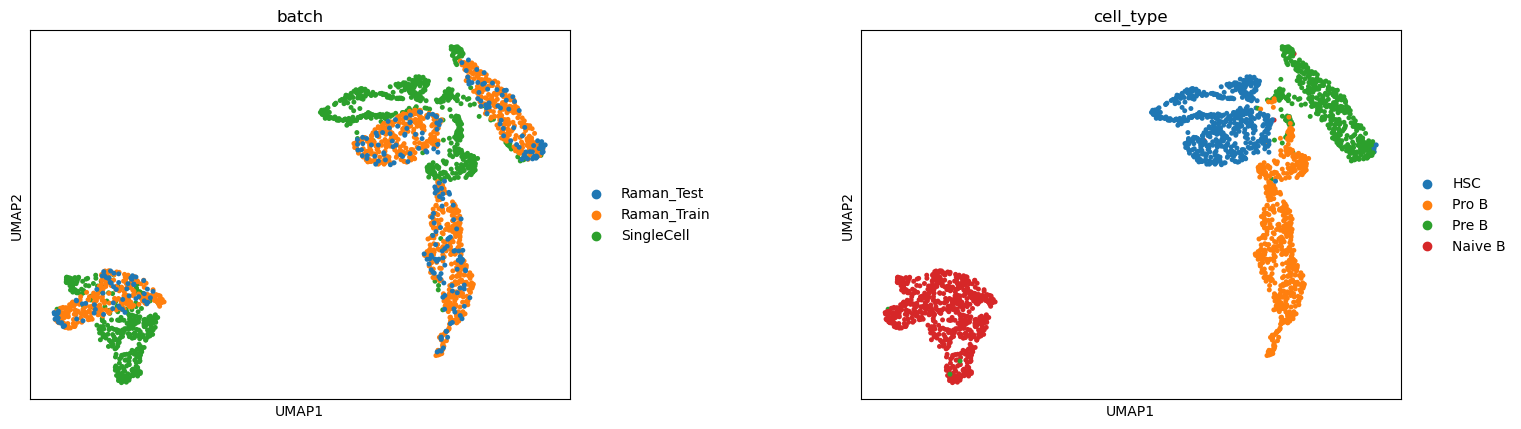

In [13]:
# ==== FIXED (2026-03-19) ====
# cuda-safe numpy conversion for AnnData construction.
# =========================
# FIXED inference: use trained latent BN and eval mode
# =========================
# Role: Expression-space UMAP of SC reconstruction and Raman->SC transferred outputs.
ref_vae = ref_vae.to(device).eval()
raman_vae = raman_vae.to(device).eval()
celltype_classifier = celltype_classifier.to(device).eval()  # optional

with torch.no_grad():
    orig_sc = torch.from_numpy(train_feature).float().to(device)
    recon_singlecell, _, _, z_sc = ref_vae(orig_sc)

    orig_rt = torch.from_numpy(raman_X_train).float().to(device)
    z_rt = raman_vae.get_latent(orig_rt)
    recon_raman_train = ref_vae.decoder(z_rt)

    orig_rv = torch.from_numpy(raman_X_test).float().to(device)
    z_rv = raman_vae.get_latent(orig_rv)
    recon_raman_test = ref_vae.decoder(z_rv)

recon_adata_singlecell = sc.AnnData(recon_singlecell.detach().cpu().numpy())
recon_adata_singlecell.obs = train_feature_ad.obs.copy()
recon_adata_singlecell.var_names = train_feature_ad.var_names
recon_adata_singlecell.obs["batch"] = "SingleCell"

recon_adata_raman_train = sc.AnnData(recon_raman_train.detach().cpu().numpy())
recon_adata_raman_train.obs = raman_ad.obs.loc[raman_index_train].copy()
recon_adata_raman_train.var_names = train_feature_ad.var_names
recon_adata_raman_train.obs["batch"] = "Raman_Train"

recon_adata_raman_test = sc.AnnData(recon_raman_test.detach().cpu().numpy())
recon_adata_raman_test.obs = raman_ad.obs.loc[raman_index_test].copy()
recon_adata_raman_test.var_names = train_feature_ad.var_names
recon_adata_raman_test.obs["batch"] = "Raman_Test"

for ad_ in [recon_adata_singlecell, recon_adata_raman_train, recon_adata_raman_test]:
    ad_.obs["cell_type"] = pd.Categorical(ad_.obs["cell_type"], categories=classes, ordered=True)

together_recon = recon_adata_singlecell.concatenate(
    recon_adata_raman_train,
    recon_adata_raman_test,
    batch_key=None,
)

sc.pp.pca(together_recon, n_comps=30)
sc.pp.neighbors(together_recon, n_neighbors=30)
sc.tl.umap(together_recon)

fig = sc.pl.umap(together_recon, color=["batch", "cell_type"], wspace=0.4, return_fig=True)
save_figure(fig, "umap_batch_fixed_inference")


In [14]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# ==== MODIFIED (2026-03-19) ====
# Purpose: Use use_latent_norm=False in transfer_vae to match training config.
# ===============================
# =========================
# Part B1: get inferred expression from Raman via transfer_vae
# =========================
# Role: Generate Raman->SC inferred expression matrices using the transfer VAE.
import numpy as np
import torch
import scanpy as sc
import scipy as sp

transfer_vae = VAE(
    raman_vae.encoder,
    ref_vae.decoder,
    is_vae=False,
    use_latent_norm=False,
).to(device).eval()

ref_vae = ref_vae.to(device).eval()

with torch.no_grad():
    inferred_rt, _, _, latent_rt = transfer_vae(torch.from_numpy(raman_X_train).float().to(get_model_device(transfer_vae)))
    inferred_rv, _, _, latent_rv = transfer_vae(torch.from_numpy(raman_X_test).float().to(get_model_device(transfer_vae)))

inferred_rt = inferred_rt.detach().cpu().numpy()
inferred_rv = inferred_rv.detach().cpu().numpy()

# 对齐基因名（就是 HVGs）
gene_names = np.array(train_feature_ad.var_names)

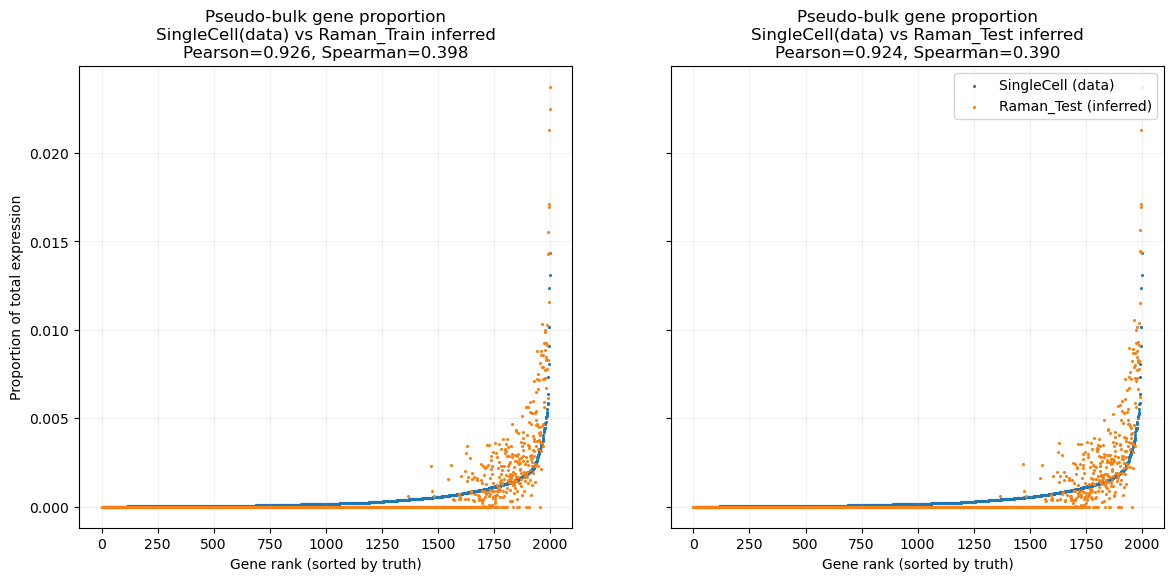

use_gene_calibration: False clip: (0.5, 2.0)
Pseudo-bulk Pearson corr (train/test): 0.925820265165609 0.9235024821358625
Pseudo-bulk Spearman corr (train/test): 0.39797147899286966 0.39025035906258976
Top200 overlap (train/test): 0.79 0.79


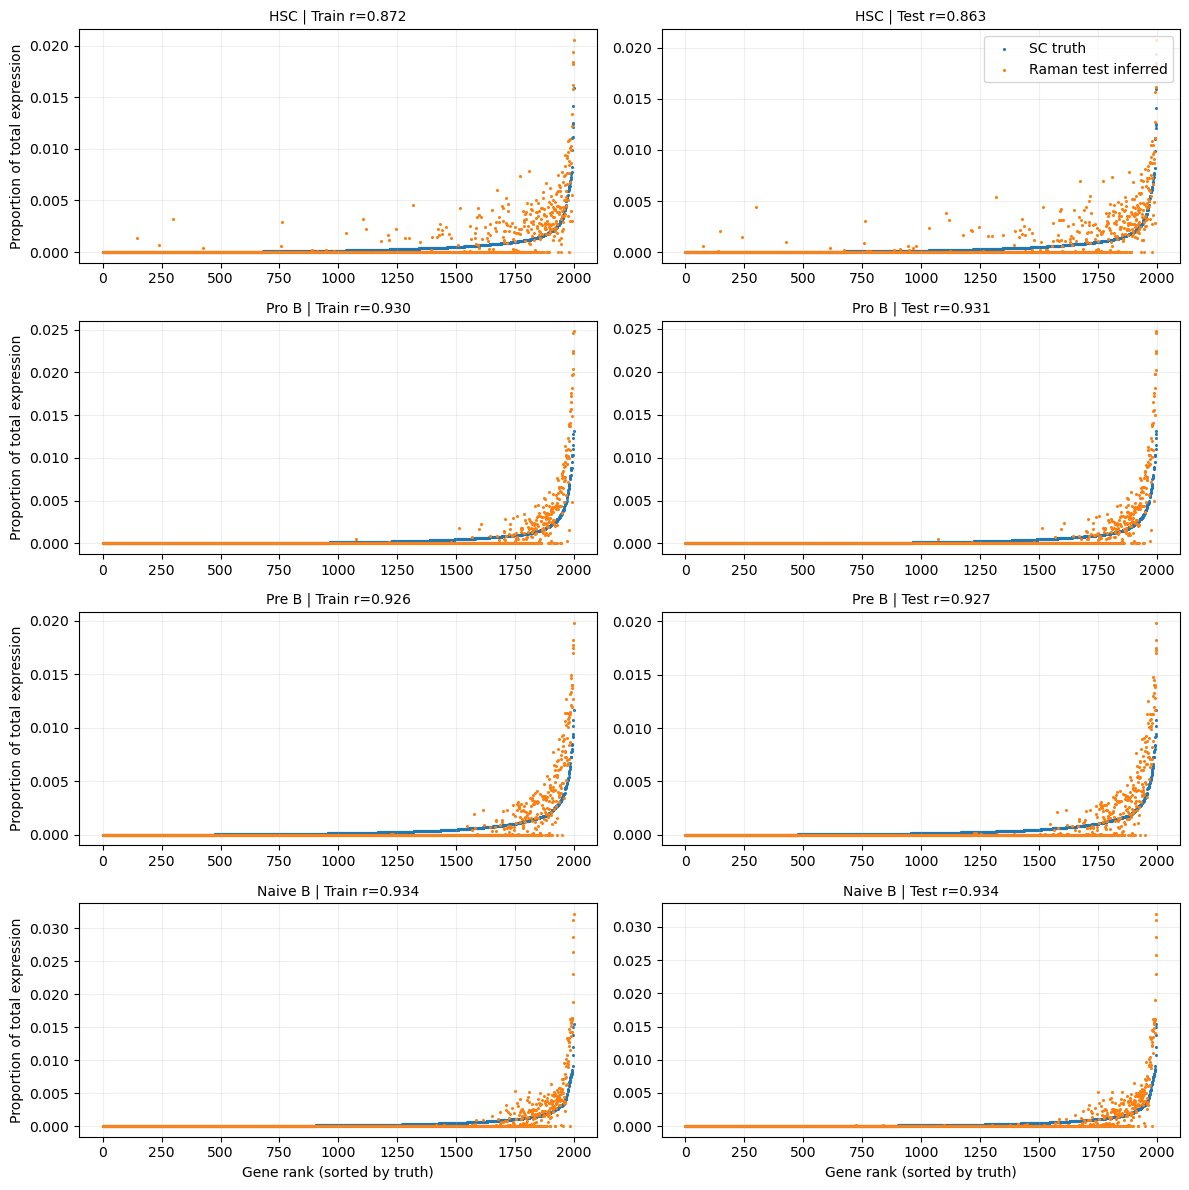

Per-cell-type pseudo-bulk Pearson correlations:
  cell_type  pearson_train  pearson_test  n_sc  n_rt  n_rv
3   Naive B       0.934044      0.934177   345   260    65
1     Pro B       0.930476      0.930714   175   345    86
2     Pre B       0.925669      0.926787   154   264    66
0       HSC       0.871760      0.862834   264   263    66


In [15]:
# ==== ENHANCED (2026-03-19) ====
# Reference-style pseudo-bulk comparison with ranked gene-proportion curves,
# plus per-cell-type ranked curves and correlation table.
# Role: Enhanced pseudo-bulk expression comparison with optional calibration and per-cell-type diagnostics.
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

if torch.is_tensor(inferred_rt):
    inferred_rt = inferred_rt.detach().cpu().numpy()
if torch.is_tensor(inferred_rv):
    inferred_rv = inferred_rv.detach().cpu().numpy()

X_truth = ensure_dense(train_feature_ad.layers["data"]).astype(np.float32)
X_rt = np.asarray(inferred_rt, dtype=np.float32)
X_rv = np.asarray(inferred_rv, dtype=np.float32)

X_truth = np.clip(X_truth, 0, None)
X_rt = np.clip(X_rt, 0, None)
X_rv = np.clip(X_rv, 0, None)

use_gene_calibration = False
calib_clip = (0.5, 2.0)
if use_gene_calibration:
    truth_gene = X_truth.mean(axis=0)
    rt_gene = X_rt.mean(axis=0)
    gene_scale = (truth_gene + 1e-8) / (rt_gene + 1e-8)
    gene_scale = np.clip(gene_scale, calib_clip[0], calib_clip[1]).astype(np.float32)
    X_rt = X_rt * gene_scale[None, :]
    X_rv = X_rv * gene_scale[None, :]

def gene_prop(X):
    s = X.sum(axis=0)
    return s / (s.sum() + 1e-12)

orig_sum = gene_prop(X_truth)
inf_sum_rt = gene_prop(X_rt)
inf_sum_rv = gene_prop(X_rv)
corr_rt = np.corrcoef(orig_sum, inf_sum_rt)[0, 1]
corr_rv = np.corrcoef(orig_sum, inf_sum_rv)[0, 1]
rank_orig = np.argsort(np.argsort(orig_sum))
rank_rt = np.argsort(np.argsort(inf_sum_rt))
rank_rv = np.argsort(np.argsort(inf_sum_rv))
spr_rt = np.corrcoef(rank_orig, rank_rt)[0, 1]
spr_rv = np.corrcoef(rank_orig, rank_rv)[0, 1]

k = 200
top_truth = set(np.argsort(orig_sum)[-k:])
top_rt = set(np.argsort(inf_sum_rt)[-k:])
top_rv = set(np.argsort(inf_sum_rv)[-k:])
ovl_rt = len(top_truth & top_rt) / k
ovl_rv = len(top_truth & top_rv) / k

ord_idx = np.argsort(orig_sum)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
s = 1.5

axes[0].set_title(f"Pseudo-bulk gene proportion\nSingleCell(data) vs Raman_Train inferred\nPearson={corr_rt:.3f}, Spearman={spr_rt:.3f}", fontsize=12)
axes[0].scatter(np.arange(len(orig_sum)), orig_sum[ord_idx], s=s, label="SingleCell (data)")
axes[0].scatter(np.arange(len(orig_sum)), inf_sum_rt[ord_idx], s=s, label="Raman_Train (inferred)")
axes[0].set_xlabel("Gene rank (sorted by truth)")
axes[0].set_ylabel("Proportion of total expression")
axes[0].grid(True, alpha=0.2)

axes[1].set_title(f"Pseudo-bulk gene proportion\nSingleCell(data) vs Raman_Test inferred\nPearson={corr_rv:.3f}, Spearman={spr_rv:.3f}", fontsize=12)
axes[1].scatter(np.arange(len(orig_sum)), orig_sum[ord_idx], s=s, label="SingleCell (data)")
axes[1].scatter(np.arange(len(orig_sum)), inf_sum_rv[ord_idx], s=s, label="Raman_Test (inferred)")
axes[1].set_xlabel("Gene rank (sorted by truth)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.2)

save_figure(fig, "expr_pseudobulk_gene_proportion_ranked")

print("use_gene_calibration:", use_gene_calibration, "clip:", calib_clip)
print("Pseudo-bulk Pearson corr (train/test):", float(corr_rt), float(corr_rv))
print("Pseudo-bulk Spearman corr (train/test):", float(spr_rt), float(spr_rv))
print(f"Top{k} overlap (train/test):", float(ovl_rt), float(ovl_rv))

cell_sc = train_feature_ad.obs["cell_type"].astype(str).values
cell_rt = raman_ad.obs.loc[raman_index_train, "cell_type"].astype(str).values
cell_rv = raman_ad.obs.loc[raman_index_test, "cell_type"].astype(str).values

rows = []
fig_ct, axes_ct = plt.subplots(len(classes), 2, figsize=(12, 3 * len(classes)), sharex=False, sharey=False)
if len(classes) == 1:
    axes_ct = np.array([axes_ct])

for r, ct in enumerate(classes):
    ct_str = str(ct)
    m_sc = cell_sc == ct_str
    m_rt = cell_rt == ct_str
    m_rv = cell_rv == ct_str
    ax_l = axes_ct[r, 0]
    ax_r = axes_ct[r, 1]

    if m_sc.sum() < 5 or m_rt.sum() < 5 or m_rv.sum() < 5:
        ax_l.text(0.5, 0.5, f"{ct_str}: insufficient cells", ha='center', va='center')
        ax_r.text(0.5, 0.5, f"{ct_str}: insufficient cells", ha='center', va='center')
        ax_l.set_axis_off(); ax_r.set_axis_off()
        continue

    p_sc = gene_prop(X_truth[m_sc])
    p_rt = gene_prop(X_rt[m_rt])
    p_rv = gene_prop(X_rv[m_rv])
    corr_ct_rt = float(np.corrcoef(p_sc, p_rt)[0, 1])
    corr_ct_rv = float(np.corrcoef(p_sc, p_rv)[0, 1])
    rows.append({
        'cell_type': ct_str,
        'pearson_train': corr_ct_rt,
        'pearson_test': corr_ct_rv,
        'n_sc': int(m_sc.sum()),
        'n_rt': int(m_rt.sum()),
        'n_rv': int(m_rv.sum()),
    })

    ord_ct = np.argsort(p_sc)
    ax_l.scatter(np.arange(len(p_sc)), p_sc[ord_ct], s=1.5, label='SC truth')
    ax_l.scatter(np.arange(len(p_sc)), p_rt[ord_ct], s=1.5, label='Raman train inferred')
    ax_l.set_title(f"{ct_str} | Train r={corr_ct_rt:.3f}", fontsize=10)
    ax_l.grid(True, alpha=0.2)

    ax_r.scatter(np.arange(len(p_sc)), p_sc[ord_ct], s=1.5, label='SC truth')
    ax_r.scatter(np.arange(len(p_sc)), p_rv[ord_ct], s=1.5, label='Raman test inferred')
    ax_r.set_title(f"{ct_str} | Test r={corr_ct_rv:.3f}", fontsize=10)
    ax_r.grid(True, alpha=0.2)

for ax in axes_ct[-1, :]:
    ax.set_xlabel("Gene rank (sorted by truth)")
for ax in axes_ct[:, 0]:
    ax.set_ylabel("Proportion of total expression")
axes_ct[0, 1].legend(loc='upper right')
fig_ct.tight_layout()
save_figure(fig_ct, "expr_pseudobulk_ranked_per_celltype")

if len(rows) > 0:
    df_ct = pd.DataFrame(rows).sort_values('pearson_test', ascending=False)
    print('Per-cell-type pseudo-bulk Pearson correlations:')
    print(df_ct)
else:
    print('Per-cell-type pseudo-bulk: no cell type had enough cells for all splits.')


In [16]:
# Role: Summarize truth and inferred expression distributions for basic quality checks.
import numpy as np
import torch

if torch.is_tensor(inferred_rt):
    inferred_rt = inferred_rt.detach().cpu().numpy()
if torch.is_tensor(inferred_rv):
    inferred_rv = inferred_rv.detach().cpu().numpy()

X_truth = ensure_dense(train_feature_ad.layers["data"]).astype(np.float32)   # lognorm
X_rt = np.asarray(inferred_rt, dtype=np.float32)
X_rv = np.asarray(inferred_rv, dtype=np.float32)

def summarize(name, X):
    row_sum = X.sum(axis=1)
    print(f"\n[{name}]")
    print("  shape:", X.shape)
    print("  min/max:", float(X.min()), float(X.max()))
    print("  row_sum mean/std:", float(row_sum.mean()), float(row_sum.std()))
    print("  pct zeros:", float((X == 0).mean()))
    # top-10 genes占比是否极端
    col_sum = X.sum(axis=0)
    p = col_sum / (col_sum.sum() + 1e-12)
    top10 = np.sort(p)[-10:].sum()
    print("  top10 gene proportion sum:", float(top10))

summarize("truth(data layer)", X_truth)
summarize("inferred Raman_Train", X_rt)
summarize("inferred Raman_Test", X_rv)


[truth(data layer)]
  shape: (938, 2000)
  min/max: 0.0 8.895095825195312
  row_sum mean/std: 410.4887390136719 77.89970397949219
  pct zeros: 0.8857627931769723
  top10 gene proportion sum: 0.09697109460830688

[inferred Raman_Train]
  shape: (1132, 2000)
  min/max: 0.0 6.171258926391602
  row_sum mean/std: 229.29505920410156 37.143306732177734
  pct zeros: 0.8916797703180211
  top10 gene proportion sum: 0.16773897409439087

[inferred Raman_Test]
  shape: (283, 2000)
  min/max: 0.0 6.1384968757629395
  row_sum mean/std: 230.21035766601562 36.77568054199219
  pct zeros: 0.8911466431095406
  top10 gene proportion sum: 0.16818657517433167


In [17]:
# ==== FIXED (2026-03-19) ====
# Remove forward-reference to original_omics; use SC normalized truth directly.
# =========================
# Part B3: pseudo-bulk correlation per cell_type
# =========================
# Role: Per-cell-type pseudo-bulk correlation table between SC truth and Raman->SC inferred expression.
import pandas as pd
import numpy as np

cell_sc = train_feature_ad.obs["cell_type"].astype(str).values
cell_rt = raman_ad.obs.loc[raman_index_train, "cell_type"].astype(str).values
cell_rv = raman_ad.obs.loc[raman_index_test,  "cell_type"].astype(str).values

def per_celltype_pseudobulk_corr(X_truth, ct_truth, X_infer, ct_infer, classes):
    rows = []
    for ct in classes:
        ct = str(ct)
        idx_t = (ct_truth == ct)
        idx_i = (ct_infer == ct)
        if idx_t.sum() < 5 or idx_i.sum() < 5:
            continue
        t = X_truth[idx_t].mean(axis=0)
        i = X_infer[idx_i].mean(axis=0)
        r = np.corrcoef(t, i)[0, 1]
        rows.append({"cell_type": ct, "n_truth": int(idx_t.sum()), "n_infer": int(idx_i.sum()), "pearson_r": float(r)})
    return pd.DataFrame(rows).sort_values("pearson_r", ascending=False)

X_truth_ct = ensure_dense(train_feature_ad.layers["data"]).astype(np.float32)

df_ct_rt = per_celltype_pseudobulk_corr(X_truth_ct, cell_sc, inferred_rt, cell_rt, classes)
df_ct_rv = per_celltype_pseudobulk_corr(X_truth_ct, cell_sc, inferred_rv, cell_rv, classes)

print("Per-cell_type pseudo-bulk corr: SingleCell vs Raman_Train inferred")
print(df_ct_rt)

print("\nPer-cell_type pseudo-bulk corr: SingleCell vs Raman_Test inferred")
print(df_ct_rv)

Per-cell_type pseudo-bulk corr: SingleCell vs Raman_Train inferred
  cell_type  n_truth  n_infer  pearson_r
3   Naive B      345      260   0.934044
1     Pro B      175      345   0.930476
2     Pre B      154      264   0.925669
0       HSC      264      263   0.871760

Per-cell_type pseudo-bulk corr: SingleCell vs Raman_Test inferred
  cell_type  n_truth  n_infer  pearson_r
3   Naive B      345       65   0.934177
1     Pro B      175       86   0.930714
2     Pre B      154       66   0.926787
0       HSC      264       66   0.862834


In [18]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# ======================================================
# Raman->SC ROC + Accuracy Table (like the provided figure)
# ======================================================
# Use transfer_vae to map Raman to SC space, then use SC classifier
# Role: Compute Raman->SC classification table using the SC classifier.
transfer_vae_eval = transfer_vae.to(device).eval()
ref_vae_eval = ref_vae.to(device).eval()
celltype_classifier_eval = celltype_classifier.to(device).eval()

with torch.no_grad():
    raman_recon, _, _, _ = transfer_vae_eval(torch.tensor(raman_X, dtype=torch.float32, device=get_model_device(transfer_vae_eval)))
    _, _, _, latent_raman2sc = ref_vae_eval(raman_recon.to(get_model_device(ref_vae_eval)))
    logits = celltype_classifier_eval(latent_raman2sc.to(get_model_device(celltype_classifier_eval)))
    probs = torch.softmax(logits, dim=1).cpu().numpy()

raman_labels = raman_y
pred = np.argmax(probs, axis=1)

# Build table
rows = []
for i, ct in enumerate(classes):
    idx = raman_labels == i
    members = int(idx.sum())
    correct = int((pred[idx] == i).sum())
    acc = 100.0 * correct / max(members, 1)
    counts = [int(((pred[idx] == j).sum())) for j in range(len(classes))]
    rows.append([ct, members, f"{acc:.2f}%"] + counts)

total_members = len(raman_labels)
correct_total = int((pred == raman_labels).sum())
acc_total = 100.0 * correct_total / max(total_members, 1)
counts_total = [int((pred == j).sum()) for j in range(len(classes))]
rows.append(["Total", total_members, f"{acc_total:.2f}%"] + counts_total)

cols = ["True", "Members", "Correct"] + list(classes)
acc_table = pd.DataFrame(rows, columns=cols)
acc_table


,True,Members,Correct,HSC,Pro B,Pre B,Naive B
0,HSC,329,95.44%,314,0,6,9
1,Pro B,325,100.00%,0,325,0,0
2,Pre B,330,100.00%,0,0,330,0
3,Naive B,431,100.00%,0,0,0,431
4,Total,1415,98.94%,314,325,336,440


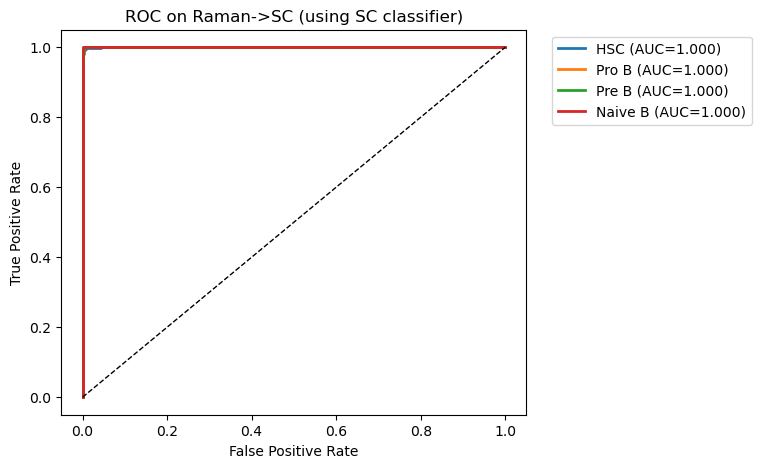

In [19]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# Validation 2: Compare classifier ROC on Raman->SC reconstructed vs true SC
# (if the ROC degrades on Raman->SC, that indicates a domain gap)
# Role: ROC evaluation of Raman->SC embeddings scored by the SC classifier.

# Build latent for Raman->SC data (through transfer_vae + ref encoder)
transfer_vae_eval = transfer_vae.to(device).eval()
ref_vae_eval = ref_vae.to(device).eval()

with torch.no_grad():
    # Raman->SC reconstruction, then encode with ref_vae encoder for classifier
    raman_recon, _, _, _ = transfer_vae_eval(torch.tensor(raman_X, dtype=torch.float32, device=get_model_device(transfer_vae_eval)))
    _, _, _, latent_raman2sc = ref_vae_eval(raman_recon.to(get_model_device(ref_vae_eval)))

latent_raman2sc_np = latent_raman2sc.detach().cpu().numpy()
raman_labels = raman_y

# Use the already trained classifier (celltype_classifier) to score Raman->SC
celltype_classifier_eval = celltype_classifier.to(device).eval()
with torch.no_grad():
    logits = celltype_classifier_eval(latent_raman2sc.to(get_model_device(celltype_classifier_eval)).float())
    probs = torch.softmax(logits, dim=1).cpu().numpy()

fig, ax = plt.subplots(figsize=(6, 5))
y_bin = label_binarize(raman_labels, classes=list(range(len(classes))))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{cls} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC on Raman->SC (using SC classifier)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
save_figure(fig, "classifier_roc_raman2sc")


In [20]:
# Role: Define marker gene sets used for downstream marker-level inspection.
marker_genes_dict_3to5 = {
    "HSC": ["CD34", "PROM1", "KIT", "GATA2", "MEIS1"],
    "Pro B": ["CYGB", "EBF1", "MME", "VPREB1", "DNTT", "IGLL1"],
    "Pre B": ["PAX5", "CD79A", "RAG1"],
    "Naive B": ["MS4A1", "CD74", "CD37", "BANK1", "TCL1A"],
}


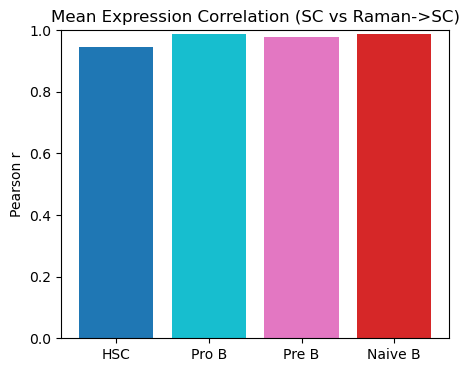

,cell_type,corr
0,HSC,0.945040
1,Pro B,0.987499
2,Pre B,0.978309
3,Naive B,0.989192


In [21]:
# ==== FIXED (2026-03-19) ====
# cuda-safe latent handling: avoid direct .numpy() on CUDA tensor.
# ==================================================================
# Cell-type mean expression correlation: SC vs Raman->SC (per cell type)
# ==================================================================
# Use together_recon with batch labels (SingleCell vs Raman_Train)
# Role: Per-cell-type mean expression correlation between SC and Raman->SC outputs.

corr_rows = []
for ct in classes:
    sc_sub = together_recon[(together_recon.obs["cell_type"] == ct) & (together_recon.obs["batch"] == "SingleCell")]
    rm_sub = together_recon[(together_recon.obs["cell_type"] == ct) & (together_recon.obs["batch"] == "Raman_Train")]
    if sc_sub.n_obs == 0 or rm_sub.n_obs == 0:
        continue

    sc_expr = sc_sub.X
    rm_expr = rm_sub.X
    if sp.sparse.issparse(sc_expr):
        sc_expr = sc_expr.toarray()
    if sp.sparse.issparse(rm_expr):
        rm_expr = rm_expr.toarray()

    sc_mean = sc_expr.mean(axis=0)
    rm_mean = rm_expr.mean(axis=0)
    corr = np.corrcoef(sc_mean, rm_mean)[0, 1]
    corr_rows.append({"cell_type": ct, "corr": corr})

corr_df = pd.DataFrame(corr_rows)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(corr_df["cell_type"], corr_df["corr"], color=palette)
ax.set_ylim(0, 1)
ax.set_title("Mean Expression Correlation (SC vs Raman->SC)")
ax.set_ylabel("Pearson r")
save_figure(fig, "mean_expr_corr_sc_vs_raman")

corr_df


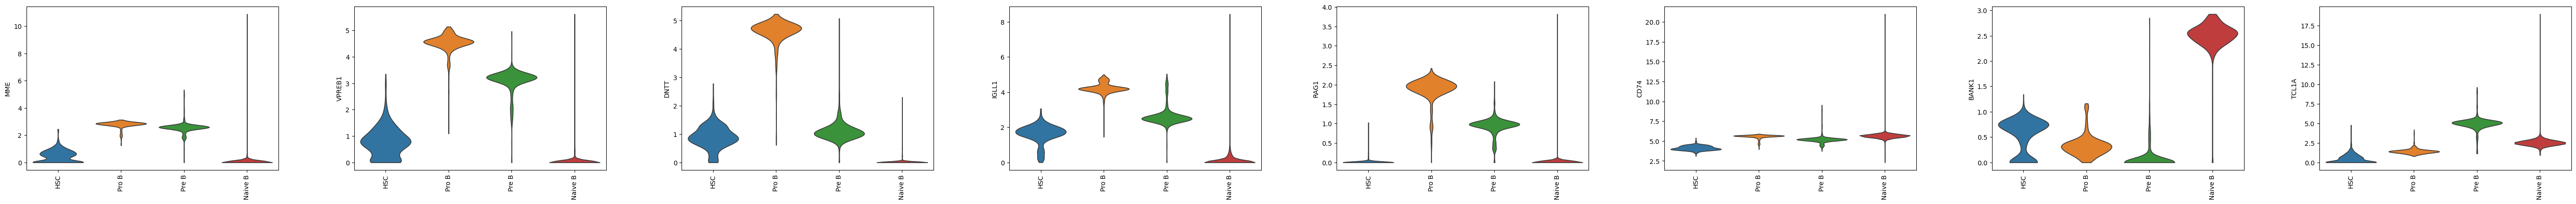

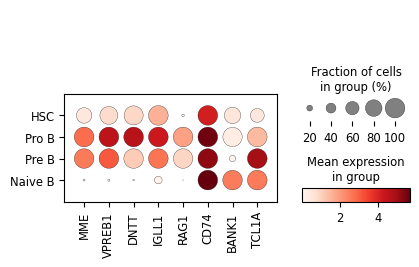

In [22]:
# =================================================
# Marker genes: violin + dotplot (SC vs Raman->SC)
# =================================================
# Role: Marker-level violin and dotplot visualization for SC and Raman->SC outputs.
marker_genes = []
for ct, genes in marker_genes_dict_3to5.items():
    marker_genes.extend(genes)
marker_genes = list(dict.fromkeys(marker_genes))
marker_genes = [g for g in marker_genes if g in together_recon.var_names]

# Violin plots split by batch
fig = sc.pl.violin(
    together_recon,
    keys=marker_genes,
    groupby="cell_type",
    stripplot=False,
    multi_panel=True,
    rotation=90,
    show=False,
)
fig = plt.gcf()
save_figure(fig, "marker_genes_violin")

# Dotplot
sc.pl.dotplot(
    together_recon,
    var_names=marker_genes,
    groupby="cell_type",
    use_raw=False,
    show=False,
)
fig = plt.gcf()
save_figure(fig, "marker_genes_dotplot")


In [23]:
# ==== NEW (2026-03-21) ====
# Role: Train an expression-aware Raman->SC model by adding decoder-space alignment to the latent-only objective.

latent_dim = 1 << 7
ref_vae = ref_vae.to(device).eval()
for p in ref_vae.parameters():
    p.requires_grad = False

celltype_classifier = celltype_classifier.to(device).eval()
for p in celltype_classifier.parameters():
    p.requires_grad = False

# Use the same split-aligned SC training set as the ref VAE/classifier.
sc_proto_x = torch.tensor(train_data, dtype=torch.float32, device=device)
sc_proto_y = torch.tensor(train_labels, dtype=torch.long, device=device)
sc_expr_proto = []
for c in range(len(classes)):
    mask = sc_proto_y == c
    if mask.sum() == 0:
        sc_expr_proto.append(torch.zeros(sc_proto_x.shape[1], device=device))
    else:
        sc_expr_proto.append(sc_proto_x[mask].mean(dim=0))
sc_expr_proto = torch.stack(sc_expr_proto, dim=0)

raman_vae_expr = VAE(
    StandardEncoder(raman_X.shape[1], latent_dim, hidden_dim=1 << 11),
    StandardDecoder(raman_X.shape[1], latent_dim, hidden_dim=1 << 11, no_final_relu=True),
    is_vae=False,
    use_latent_norm=False,
).to(device)
raman_opt_expr = optim.Adam(raman_vae_expr.parameters(), lr=5e-5)

raman_discrim_expr = Discriminator(latent_dim).to(device)
raman_discrim_opt_expr = optim.Adam(raman_discrim_expr.parameters(), lr=4e-3)

alpha_expr = 1.0
beta_expr = 1e-2
raman_beta_expr = 10.0
expr_beta = 10.0

epochs_raman_expr = 50
loss_adv_expr = []
loss_ct_expr = []
loss_disc_expr = []
loss_expr_align = []
domain_acc_expr = []

ref_data_loader_expr = DataLoader(
    TensorDataset(torch.tensor(train_data, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=True,
)

for epoch in range(1, epochs_raman_expr + 1):
    ref_iter = iter(ref_data_loader_expr)
    running_adv = 0.0
    running_ct = 0.0
    running_disc = 0.0
    running_expr = 0.0
    seen = 0

    for raman_batch, raman_ct in raman_train_loader:
        try:
            (ref_batch,) = next(ref_iter)
        except StopIteration:
            ref_iter = iter(ref_data_loader_expr)
            (ref_batch,) = next(ref_iter)

        ref_batch = ref_batch.to(device)
        raman_batch = raman_batch.to(device)
        raman_ct = raman_ct.to(device)
        bs = raman_batch.size(0)

        raman_opt_expr.zero_grad()
        raman_discrim_opt_expr.zero_grad()

        z_ref = ref_vae.get_latent(ref_batch).detach()
        z_ram = raman_vae_expr.get_latent(raman_batch).detach()
        dom_labels = torch.tensor(
            [[1.0, 0.0]] * z_ref.shape[0] + [[0.0, 1.0]] * z_ram.shape[0],
            dtype=torch.float32,
            device=device,
        )
        dom_pred = raman_discrim_expr(torch.cat([z_ref, z_ram], dim=0))
        dloss = discrim_loss(dom_pred, dom_labels)
        dloss.backward()
        raman_discrim_opt_expr.step()
        running_disc += dloss.item() * bs

        for p in raman_discrim_expr.parameters():
            p.requires_grad = False

        recon_ram, mean_ram, logvar_ram, latent_ram = raman_vae_expr(raman_batch)
        adv_pred = raman_discrim_expr(latent_ram)
        gloss, _, _ = adv_vae_loss(
            raman_batch.detach(), recon_ram, mean_ram, logvar_ram, adv_pred,
            alpha_expr, beta_expr,
        )
        ct_logits = celltype_classifier(latent_ram)
        ct_loss = criter(ct_logits, raman_ct)

        decoded_sc = ref_vae.decoder(latent_ram)
        expr_loss = torch.zeros((), device=device)
        valid_classes = 0
        for c in torch.unique(raman_ct):
            m = raman_ct == c
            if m.sum() == 0:
                continue
            expr_loss = expr_loss + F.mse_loss(decoded_sc[m].mean(dim=0), sc_expr_proto[int(c.item())])
            valid_classes += 1
        if valid_classes > 0:
            expr_loss = expr_loss / valid_classes

        total_loss = gloss + raman_beta_expr * ct_loss + expr_beta * expr_loss
        total_loss.backward()
        raman_opt_expr.step()

        for p in raman_discrim_expr.parameters():
            p.requires_grad = True

        running_adv += total_loss.item() * bs
        running_ct += ct_loss.item() * bs
        running_expr += expr_loss.item() * bs
        seen += bs

    with torch.no_grad():
        z_ref_all = ref_vae.get_latent(torch.tensor(train_feature, dtype=torch.float32, device=device))
        z_ram_all = raman_vae_expr.get_latent(torch.tensor(raman_X, dtype=torch.float32, device=device))
        pred_all = torch.argmax(raman_discrim_expr(torch.cat([z_ref_all, z_ram_all], dim=0)), dim=1).cpu().numpy()
        y_all = np.array([0] * z_ref_all.shape[0] + [1] * z_ram_all.shape[0])
        dacc = float((pred_all == y_all).mean())

    loss_adv_expr.append(running_adv / max(seen, 1))
    loss_ct_expr.append(running_ct / max(seen, 1))
    loss_disc_expr.append(running_disc / max(seen, 1))
    loss_expr_align.append(running_expr / max(seen, 1))
    domain_acc_expr.append(dacc)

    print(
        f'ExprAware Epoch {epoch}: total={loss_adv_expr[-1]:.6f}, '
        f'ct={loss_ct_expr[-1]:.6f}, expr={loss_expr_align[-1]:.6f}, '
        f'disc={loss_disc_expr[-1]:.6f}, dacc={domain_acc_expr[-1]:.4f}'
    )


ExprAware Epoch 1: total=4.856263, ct=0.418641, expr=0.059110, disc=0.368944, dacc=0.9983
ExprAware Epoch 2: total=1.546428, ct=0.107395, expr=0.044327, disc=0.130783, dacc=0.9975
ExprAware Epoch 3: total=1.196384, ct=0.074391, expr=0.042448, disc=0.094690, dacc=0.9983
ExprAware Epoch 4: total=1.087804, ct=0.065241, expr=0.040844, disc=0.094109, dacc=0.9987
ExprAware Epoch 5: total=0.971392, ct=0.054521, expr=0.039897, disc=0.094103, dacc=0.9970
ExprAware Epoch 6: total=0.917145, ct=0.048382, expr=0.040473, disc=0.079394, dacc=0.9992
ExprAware Epoch 7: total=0.998300, ct=0.058621, expr=0.038377, disc=0.079718, dacc=0.9992
ExprAware Epoch 8: total=0.779360, ct=0.036985, expr=0.038049, disc=0.074476, dacc=0.9992
ExprAware Epoch 9: total=0.731463, ct=0.032753, expr=0.037500, disc=0.071329, dacc=0.9992
ExprAware Epoch 10: total=0.527474, ct=0.012855, expr=0.036882, disc=0.066777, dacc=0.9996
ExprAware Epoch 11: total=0.589502, ct=0.019343, expr=0.036627, disc=0.071100, dacc=0.9996
ExprAwar

/tmp/ipykernel_201112/2899447879.py:34: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  together_recon_expr = recon_adata_singlecell_expr.concatenate(


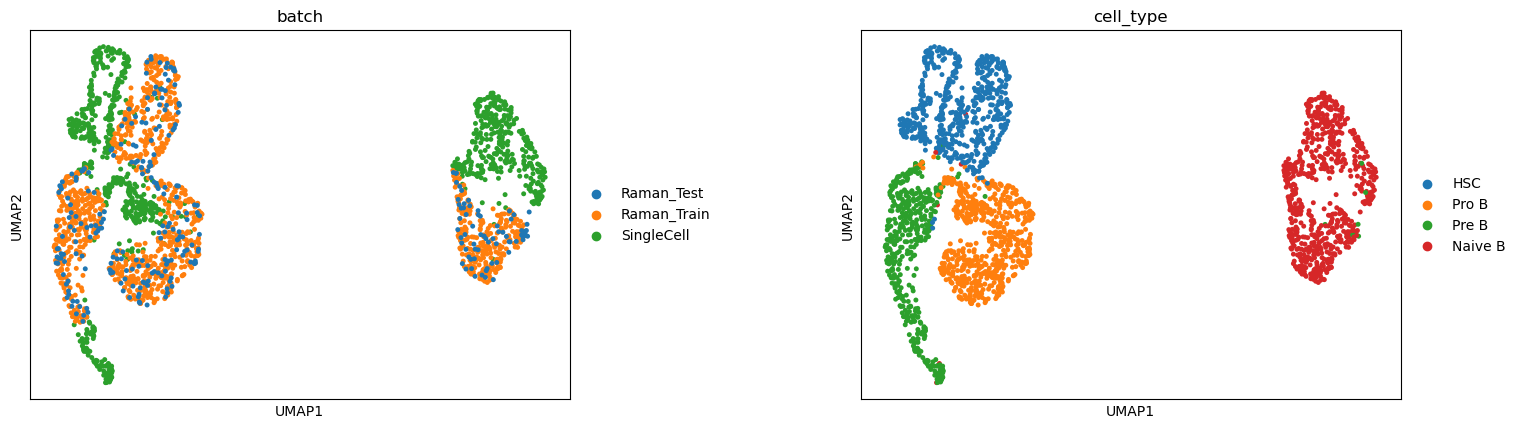

NameError: name 'evaluate_alignment_metrics' is not defined

In [24]:
# ==== NEW (2026-03-21) ====
# Role: Evaluate the expression-aware branch with expression-space UMAP and summary metrics.

transfer_vae_expr = VAE(
    raman_vae_expr.encoder,
    ref_vae.decoder,
    is_vae=False,
    use_latent_norm=False,
).to(device).eval()

with torch.no_grad():
    recon_sc_expr = ref_vae(torch.from_numpy(train_feature).float().to(device))[0]
    recon_rt_expr = transfer_vae_expr(torch.from_numpy(raman_X_train).float().to(device))[0]
    recon_rv_expr = transfer_vae_expr(torch.from_numpy(raman_X_test).float().to(device))[0]

recon_adata_singlecell_expr = sc.AnnData(recon_sc_expr.detach().cpu().numpy())
recon_adata_singlecell_expr.obs = train_feature_ad.obs.copy()
recon_adata_singlecell_expr.var_names = train_feature_ad.var_names
recon_adata_singlecell_expr.obs['batch'] = 'SingleCell'

recon_adata_raman_train_expr = sc.AnnData(recon_rt_expr.detach().cpu().numpy())
recon_adata_raman_train_expr.obs = raman_ad.obs.loc[raman_index_train].copy()
recon_adata_raman_train_expr.var_names = train_feature_ad.var_names
recon_adata_raman_train_expr.obs['batch'] = 'Raman_Train'

recon_adata_raman_test_expr = sc.AnnData(recon_rv_expr.detach().cpu().numpy())
recon_adata_raman_test_expr.obs = raman_ad.obs.loc[raman_index_test].copy()
recon_adata_raman_test_expr.var_names = train_feature_ad.var_names
recon_adata_raman_test_expr.obs['batch'] = 'Raman_Test'

for ad_ in [recon_adata_singlecell_expr, recon_adata_raman_train_expr, recon_adata_raman_test_expr]:
    ad_.obs['cell_type'] = pd.Categorical(ad_.obs['cell_type'], categories=classes, ordered=True)

together_recon_expr = recon_adata_singlecell_expr.concatenate(
    recon_adata_raman_train_expr,
    recon_adata_raman_test_expr,
    batch_key=None,
)
sc.pp.pca(together_recon_expr, n_comps=30)
sc.pp.neighbors(together_recon_expr, n_neighbors=30)
sc.tl.umap(together_recon_expr)
fig = sc.pl.umap(together_recon_expr, color=['batch', 'cell_type'], wspace=0.4, return_fig=True)
save_figure(fig, 'umap_batch_expraware')

def evaluate_alignment_metrics_inline(ref_model, raman_model, discrim_model, device):
    ref_model = ref_model.to(device).eval()
    raman_model = raman_model.to(device).eval()
    discrim_model = discrim_model.to(device).eval()
    with torch.no_grad():
        z_ref = ref_model.get_latent(torch.tensor(train_feature, dtype=torch.float32, device=device))
        z_ram = raman_model.get_latent(torch.tensor(raman_X, dtype=torch.float32, device=device))
        pred = torch.argmax(discrim_model(torch.cat([z_ref, z_ram], dim=0)), dim=1).cpu().numpy()
        y = np.array([0] * z_ref.shape[0] + [1] * z_ram.shape[0])
        domain_acc = float((pred == y).mean())

    def gene_prop(X):
        s = X.sum(axis=0)
        return s / (s.sum() + 1e-12)

    with torch.no_grad():
        transfer_eval = VAE(raman_model.encoder, ref_model.decoder, is_vae=False, use_latent_norm=False).to(device).eval()
        inf_rt = transfer_eval(torch.tensor(raman_X_train, dtype=torch.float32, device=device))[0].detach().cpu().numpy()
        inf_rv = transfer_eval(torch.tensor(raman_X_test, dtype=torch.float32, device=device))[0].detach().cpu().numpy()
    truth = ensure_dense(train_feature_ad.layers['data']).astype(np.float32)
    pb_corr_train = float(np.corrcoef(gene_prop(truth), gene_prop(np.clip(inf_rt, 0, None)))[0, 1])
    pb_corr_test = float(np.corrcoef(gene_prop(truth), gene_prop(np.clip(inf_rv, 0, None)))[0, 1])
    return {
        'domain_acc': domain_acc,
        'pb_corr_train': pb_corr_train,
        'pb_corr_test': pb_corr_test,
    }

metrics_expraware = evaluate_alignment_metrics_inline(ref_vae, raman_vae_expr, raman_discrim_expr, device)
print('Expression-aware metrics:', metrics_expraware)
